# HW13 – Токенизация, инференс BERT и fine-tuning для классификации текста

Датасет: **`emotion`** (HuggingFace datasets)  
Задача: 6-классовая классификация эмоций в коротких англоязычных текстах  
Модель: `distilbert-base-uncased`


In [1]:
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline,
)

In [2]:
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Torch version: {torch.__version__}")

import transformers, datasets
print(f"Transformers: {transformers.__version__}")
print(f"Datasets: {datasets.__version__}")


Device: cpu
Torch version: 2.10.0+cpu
Transformers: 5.5.0
Datasets: 4.8.4


## 1. Данные и первичный анализ

In [3]:
raw_datasets = load_dataset("emotion")
print(raw_datasets)


Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 138471.57 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [4]:
# Размеры сплитов
for split_name, split_data in raw_datasets.items():
    print(f"{split_name:12s}: {len(split_data):>6} примеров")


train       :  16000 примеров
validation  :   2000 примеров
test        :   2000 примеров


In [5]:
# Названия классов
label_names = raw_datasets["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}
num_labels = len(label_names)

print(f"Число классов: {num_labels}")
print(f"Классы: {label_names}")


Число классов: 6
Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [6]:
# Несколько примеров текстов и меток
sample_df = pd.DataFrame(raw_datasets["train"][:5])
sample_df["label_name"] = sample_df["label"].map(id2label)
display(sample_df)


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Распределение классов в train:
label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


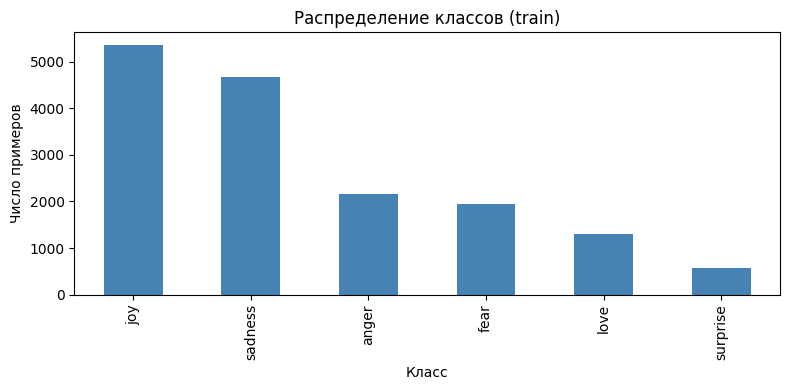


Мин. класс: 572, Макс. класс: 5362, Дисбаланс: 9.4x


In [7]:
# Распределение классов в train
train_df = pd.DataFrame(raw_datasets["train"])
train_df["label_name"] = train_df["label"].map(id2label)

counts = train_df["label_name"].value_counts()
print("Распределение классов в train:")
print(counts)

counts.plot(kind="bar", title="Распределение классов (train)", figsize=(8, 4), color="steelblue")
plt.ylabel("Число примеров")
plt.xlabel("Класс")
plt.tight_layout()
plt.show()

print(f"\nМин. класс: {counts.min()}, Макс. класс: {counts.max()}, Дисбаланс: {counts.max()/counts.min():.1f}x")


## 2. Токенизация

In [8]:
# Загрузка токенизатора
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Класс токенизатора:", tokenizer.__class__.__name__)
print("Словарь (vocab_size):", tokenizer.vocab_size)
print("Модель:", MODEL_NAME)


Класс токенизатора: BertTokenizer
Словарь (vocab_size): 30522
Модель: distilbert-base-uncased


In [ ]:
# особые токены модели
special_tokens = {
    "cls_token":  tokenizer.cls_token,
    "sep_token":  tokenizer.sep_token,
    "pad_token":  tokenizer.pad_token,
    "unk_token":  tokenizer.unk_token,
    "mask_token": tokenizer.mask_token,
}
for name, tok in special_tokens.items():
    print(f"{name:15s}: {tok!r:10s}  id={tokenizer.convert_tokens_to_ids(tok)}")


cls_token      : '[CLS]'     id=101
sep_token      : '[SEP]'     id=102
pad_token      : '[PAD]'     id=0
unk_token      : '[UNK]'     id=100
mask_token     : '[MASK]'    id=103


In [28]:
# Разбор токенизации на 5 примерах
sample_texts_tok = [
    "I feel so happy today!",
    "This is absolutely terrifying and I lost my labuba.",
    "I'm really angry about what happened. I became a clown.",
    "She seemed surprised by the news.",
    "I love spending time with my dream-family.",
]

rows = []
for text in sample_texts_tok:
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.encode(text)
    rows.append({"text": text[:40], "tokens": tokens, "input_ids": ids[:10], "n_tokens": len(tokens)})

tok_df = pd.DataFrame(rows)
display(tok_df)


,text,tokens,input_ids,n_tokens
0,I feel so happy today!,"[i, feel, so, happy, today, !]","[101, 1045, 2514, 2061, 3407, 2651, 999, 102]",6
1,This is absolutely terrifying and I lost,"[this, is, absolutely, terrifying, and, i, los...","[101, 2023, 2003, 7078, 17082, 1998, 1045, 243...",11
2,I'm really angry about what happened. I,"[i, ', m, really, angry, about, what, happened...","[101, 1045, 1005, 1049, 2428, 4854, 2055, 2054...",14
3,She seemed surprised by the news.,"[she, seemed, surprised, by, the, news, .]","[101, 2016, 2790, 4527, 2011, 1996, 2739, 1012...",7
4,I love spending time with my dream-famil,"[i, love, spending, time, with, my, dream, -, ...","[101, 1045, 2293, 5938, 2051, 2007, 2026, 3959...",10


In [11]:
short_text = "I feel happy."
long_text = " ".join(["word"] * 60)

encoded_batch = tokenizer(
    [short_text, long_text],
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors="pt",
)

for key in ["input_ids", "attention_mask"]:
    print(f"\n{key}  shape={tuple(encoded_batch[key].shape)}")
    print(encoded_batch[key])



input_ids  shape=(2, 32)
tensor([[ 101, 1045, 2514, 3407, 1012,  102,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0],
        [ 101, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773,
         2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773,
         2773, 2773, 2773, 2773, 2773, 2773, 2773,  102]])

attention_mask  shape=(2, 32)
tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]])


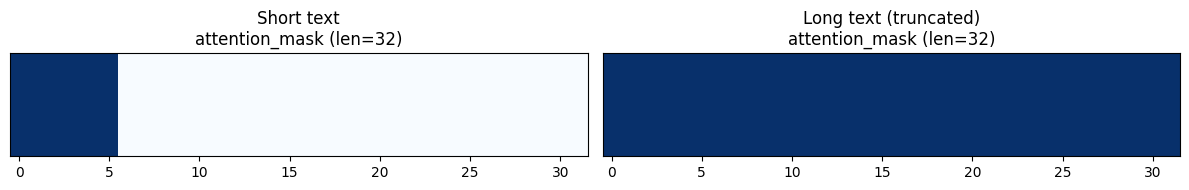

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 2))
for i, (title, text) in enumerate(zip(["Short text", "Long text (truncated)"], [short_text, long_text])):
    mask = encoded_batch["attention_mask"][i].numpy()
    axes[i].imshow(mask.reshape(1, -1), cmap="Blues", aspect="auto", vmin=0, vmax=1)
    axes[i].set_title(f"{title}\nattention_mask (len={len(mask)})")
    axes[i].set_yticks([])
plt.tight_layout()
plt.show()


## 3. Инференс готовой pretrained модели

In [13]:
pretrained_model_name = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_pipeline = pipeline(
    "text-classification",
    model=pretrained_model_name,
    device=0 if torch.cuda.is_available() else -1,
)

inference_texts = [
    "I feel so happy and excited!",
    "This is making me really angry.",
    "I'm terrified of what's going to happen.",
    "What a surprise, I didn't expect this at all!",
    "I feel nothing, just empty inside.",
    "I love you so much!",
]

results = sentiment_pipeline(inference_texts)
inference_df = pd.DataFrame({
    "text": inference_texts,
    "pred_label": [r["label"] for r in results],
    "confidence": [round(r["score"], 3) for r in results],
})
display(inference_df)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8198.16it/s]


,text,pred_label,confidence
0,I feel so happy and excited!,POSITIVE,1.000
1,This is making me really angry.,NEGATIVE,0.999
2,I'm terrified of what's going to happen.,NEGATIVE,0.999
3,"What a surprise, I didn't expect this at all!",POSITIVE,0.997
4,"I feel nothing, just empty inside.",NEGATIVE,0.998
5,I love you so much!,POSITIVE,1.000


In [27]:
print("""
Готовая модель обучена на бинарную классификацию: POSITIVE / NEGATIVE.
Моя задача — 6 классов: sadness, joy, love, anger, fear, surprise.

Выводы:
- Готовая модель не имеет классов love, anger, fear, surprise — она «видит» только
  позитив/негатив, что довольно-таки выходит грубо, если нужны оттенки эмоций.
- Fine-tuning необходим, чтобы модель научилась различать 6 конкретных эмоций.
""")



Готовая модель обучена на бинарную классификацию: POSITIVE / NEGATIVE.
Моя задача — 6 классов: sadness, joy, love, anger, fear, surprise.

Выводы:
- Готовая модель не имеет классов love, anger, fear, surprise — она «видит» только
  позитив/негатив, что довольно-таки выходит грубо, если нужны оттенки эмоций.
- Fine-tuning необходим, чтобы модель научилась различать 6 конкретных эмоций.



## 4. Fine-tuning для классификации

In [15]:
# Токенизация всего датасета
MAX_LENGTH = 128

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

tokenized_datasets = raw_datasets.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets.set_format("torch")

print("Токенизированный датасет:")
print(tokenized_datasets)


Map: 100%|██████████| 2000/2000 [00:00<00:00, 14961.30 examples/s]

Токенизированный датасет:
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [16]:
# DataCollator и модель
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model_ft = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model_ft.to(device)

print(f"Модель: {MODEL_NAME}")
print(f"Число классов: {model_ft.config.num_labels}")
print(f"id2label: {model_ft.config.id2label}")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8307.36it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель: distilbert-base-uncased
Число классов: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [17]:
# Функция метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}


In [ ]:
# Параметры обучения
import inspect
from transformers import TrainingArguments

sig = inspect.signature(TrainingArguments.__init__)
use_eval_strategy = "eval_strategy" in sig.parameters

common_kwargs = dict(
    output_dir="outputs/hw13_emotion",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    logging_steps=50,
    seed=SEED,
)

if use_eval_strategy:
    common_kwargs["eval_strategy"] = "epoch"
    common_kwargs["save_strategy"] = "epoch"
else:
    common_kwargs["evaluation_strategy"] = "epoch"
    common_kwargs["save_strategy"] = "epoch"

training_args = TrainingArguments(**common_kwargs)


In [19]:
# Создание Trainer и запуск обучения
try:
    trainer = Trainer(
        model=model_ft,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model_ft,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

print("Trainer создан, запускаем обучение...")
trainer.train()


Trainer создан, запускаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.237029,0.204107,0.928000,0.900689,0.928274
2,0.141328,0.165244,0.930000,0.905017,0.929619
3,0.108986,0.154497,0.932500,0.904371,0.932562


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.50it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1500, training_loss=0.29781334559122724, metrics={'train_runtime': 3138.0466, 'train_samples_per_second': 15.296, 'train_steps_per_second': 0.478, 'total_flos': 647803507542912.0, 'train_loss': 0.29781334559122724, 'epoch': 3.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.547929,2.681142,0.000019,0.1,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.142741,6.519114,0.000019,0.2,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.807087,7.395734,0.000018,0.3,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.625685,6.118782,0.000017,0.4,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.449581,5.232961,0.000017,0.5,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.359190,5.722621,0.000016,0.6,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.333122,6.951009,0.000015,0.7,350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.288524,3.452390,0.000015,0.8,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.267328,10.108459,0.000014,0.9,450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.237029,4.255670,0.000013,1.0,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


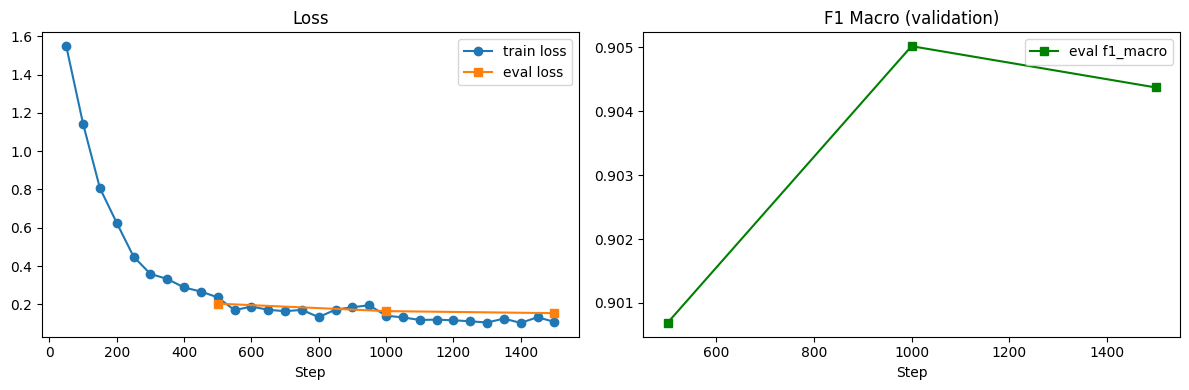

In [20]:
# Кривые обучения
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    axes[0].plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")
if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    axes[0].plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Step")
axes[0].legend()

if "eval_f1_macro" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_f1_macro"])
    axes[1].plot(eval_logs["step"], eval_logs["eval_f1_macro"], marker="s", color="green", label="eval f1_macro")
axes[1].set_title("F1 Macro (validation)")
axes[1].set_xlabel("Step")
axes[1].legend()

plt.tight_layout()
plt.savefig("artifacts/training_curves.png", dpi=100, bbox_inches="tight")
plt.show()


## 5. Оценка качества

In [21]:
# Оценка на validation и test
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("^-^ Validation ^-^")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print("\n^-^ Test ^-^")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


^-^ Validation ^-^
  eval_loss: 0.1652
  eval_accuracy: 0.9300
  eval_f1_macro: 0.9050
  eval_f1_weighted: 0.9296
  eval_runtime: 34.5415
  eval_samples_per_second: 57.9010
  eval_steps_per_second: 0.9260
  epoch: 3.0000

^-^ Test ^-^
  eval_loss: 0.1792
  eval_accuracy: 0.9195
  eval_f1_macro: 0.8737
  eval_f1_weighted: 0.9194
  eval_runtime: 33.7686
  eval_samples_per_second: 59.2270
  eval_steps_per_second: 0.9480
  epoch: 3.0000


In [22]:
# Детальные предсказания на test
test_output = trainer.predict(tokenized_datasets["test"])
test_preds = np.argmax(test_output.predictions, axis=-1)
test_true  = test_output.label_ids
test_probs = torch.softmax(torch.tensor(test_output.predictions), dim=-1).numpy()
test_conf  = test_probs.max(axis=-1)

print("Classification Report (test):")
print(classification_report(
    test_true, test_preds,
    target_names=label_names,
))

test_acc    = accuracy_score(test_true, test_preds)
test_f1_mac = f1_score(test_true, test_preds, average="macro")
print(f"test_accuracy  = {test_acc:.4f}")
print(f"test_f1_macro  = {test_f1_mac:.4f}")


Classification Report (test):
              precision    recall  f1-score   support

     sadness       0.95      0.97      0.96       581
         joy       0.94      0.95      0.94       695
        love       0.85      0.76      0.80       159
       anger       0.96      0.88      0.92       275
        fear       0.87      0.88      0.88       224
    surprise       0.68      0.82      0.74        66

    accuracy                           0.92      2000
   macro avg       0.87      0.88      0.87      2000
weighted avg       0.92      0.92      0.92      2000

test_accuracy  = 0.9195
test_f1_macro  = 0.8737


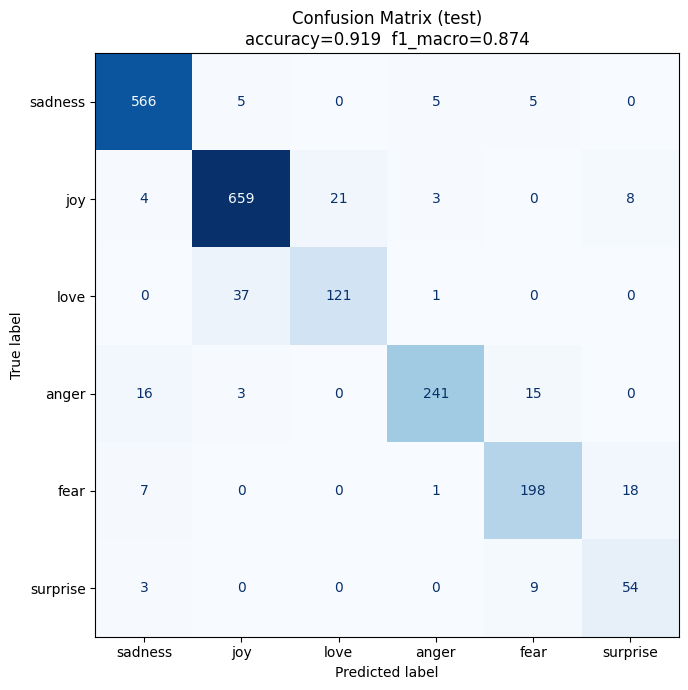

In [23]:
# Матрица ошибок
cm = confusion_matrix(test_true, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix (test)\naccuracy={test_acc:.3f}  f1_macro={test_f1_mac:.3f}")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


In [24]:
# Примеры предсказаний (sample_predictions.csv)
test_texts_raw = raw_datasets["test"]["text"]
test_true_labels = [id2label[i] for i in test_true]
test_pred_labels = [id2label[i] for i in test_preds]

pred_df = pd.DataFrame({
    "text":       test_texts_raw,
    "true_label": test_true_labels,
    "pred_label": test_pred_labels,
    "confidence": test_conf.round(3),
    "correct":    [t == p for t, p in zip(test_true_labels, test_pred_labels)],
})

# Показываем 20 примеров
display(pred_df.head(20))

pred_df.to_csv("artifacts/sample_predictions.csv", index=False)


,text,true_label,pred_label,confidence,correct
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.993,True
1,im updating my blog because i feel shitty,sadness,sadness,0.996,True
2,i never make her separate from me because i do...,sadness,sadness,0.995,True
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.994,True
4,i was feeling a little vain when i did this one,sadness,sadness,0.995,True
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.988,True
6,i felt anger when at the end of a telephone call,anger,anger,0.965,True
7,i explain why i clung to a relationship with a...,joy,joy,0.759,True
8,i like to have the same breathless feeling as ...,joy,joy,0.994,True
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.990,True


In [25]:
# Анализ ошибок
errors_df = pred_df[~pred_df["correct"]].copy()
print(f"Всего ошибок: {len(errors_df)} из {len(pred_df)}")
print(f"Accuracy: {1 - len(errors_df)/len(pred_df):.4f}\n")

print("^-^ Примеры ошибок ^-^")
display(errors_df.head(10)[["text", "true_label", "pred_label", "confidence"]])


Всего ошибок: 161 из 2000
Accuracy: 0.9195

^-^ Примеры ошибок ^-^


,text,true_label,pred_label,confidence
40,i feel if i completely hated things i d exerci...,anger,sadness,0.669
67,i feel a bit stressed even though all the thin...,anger,sadness,0.795
86,i feel like i am in paradise kissing those swe...,joy,love,0.504
93,i was feeling weird the other day and it went ...,fear,surprise,0.626
94,when a friend dropped a frog down my neck,anger,fear,0.767
96,i love neglecting this blog but sometimes i fe...,love,joy,0.803
98,i feel my heart is tortured by what i have done,anger,fear,0.531
108,i looked at mabel this morning i named my left...,fear,surprise,0.718
111,i feel is he generous,love,joy,0.575
125,i feel very mislead by someone that i really r...,love,anger,0.823


ошибки связаны с тем, что оттенки эмоций могут пересекаться

In [26]:
def predict_texts_ft(texts):
    enc = tokenizer(
        texts, return_tensors="pt", padding=True,
        truncation=True, max_length=MAX_LENGTH,
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    model_ft.eval()
    with torch.no_grad():
        logits = model_ft(**enc).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = probs.argmax(axis=-1)
    return pd.DataFrame({
        "text":       texts,
        "pred_label": [id2label[p] for p in preds],
        "confidence": probs.max(axis=-1).round(3),
    })

new_texts = [
    "I'm so scared, I don't know what to do.",
    "This is the best day of my life, I'm overjoyed!",
    "I can't believe they did this to me, I'm furious.",
    "I'm shocked by the unexpected turn of events.",
    "I feel completely empty and hopeless.",
    "My heart is full of love for everyone around me.",
]

display(predict_texts_ft(new_texts))


,text,pred_label,confidence
0,"I'm so scared, I don't know what to do.",fear,0.991
1,"This is the best day of my life, I'm overjoyed!",joy,0.987
2,"I can't believe they did this to me, I'm furious.",anger,0.986
3,I'm shocked by the unexpected turn of events.,surprise,0.958
4,I feel completely empty and hopeless.,sadness,0.995
5,My heart is full of love for everyone around me.,joy,0.505


## Итоги

Fine-tuning `distilbert-base-uncased` на датасете `emotion` (6 классов) за 3 эпохи  
даёт значительно лучшие результаты по сравнению с инференсом готовой SST-2 модели,  
поскольку задача 6-классовой классификации эмоций принципиально отличается от бинарного анализа тональности.

Файлы в `artifacts/`:
- `sample_predictions.csv` — предсказания на test
- `confusion_matrix.png` — матрица ошибок на test
- `training_curves.png` — кривые обучения
